In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\omera\OneDrive - student.uet.edu.pk\Data Science\COVID-19 Data Analysis\data\WHO-COVID-19-global-data.csv")
df.head()

,Date_reported,Country_code,Country,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
0,2020-01-05,AF,Afghanistan,EMRO,NaN,0,NaN,0
1,2020-01-12,AF,Afghanistan,EMRO,NaN,0,NaN,0
2,2020-01-19,AF,Afghanistan,EMRO,NaN,0,NaN,0
3,2020-01-26,AF,Afghanistan,EMRO,NaN,0,NaN,0
4,2020-02-02,AF,Afghanistan,EMRO,NaN,0,NaN,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64080 entries, 0 to 64079
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date_reported      64080 non-null  object 
 1   Country_code       63813 non-null  object 
 2   Country            64080 non-null  object 
 3   WHO_region         59274 non-null  object 
 4   New_cases          46683 non-null  float64
 5   Cumulative_cases   64080 non-null  int64  
 6   New_deaths         46837 non-null  float64
 7   Cumulative_deaths  64080 non-null  int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 3.9+ MB


In [3]:
df.describe()

,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
count,4.668300e+04,6.408000e+04,46837.00000,6.408000e+04
mean,1.665243e+04,1.933231e+06,151.34951,2.093310e+04
std,2.476953e+05,8.212015e+06,898.49581,8.461920e+04
min,-6.507900e+04,0.000000e+00,-3432.00000,0.000000e+00
25%,1.100000e+01,5.507000e+03,0.00000,3.400000e+01
50%,1.940000e+02,5.204100e+04,1.00000,6.640000e+02
75%,2.542000e+03,6.122352e+05,25.00000,7.572000e+03
max,4.047548e+07,1.034368e+08,47687.00000,1.216819e+06


In [4]:
df.isnull().sum()

Date_reported            0
Country_code           267
Country                  0
WHO_region            4806
New_cases            17397
Cumulative_cases         0
New_deaths           17243
Cumulative_deaths        0
dtype: int64

In [5]:
df.duplicated().sum()

0

In [6]:
df.columns

Index(['Date_reported', 'Country_code', 'Country', 'WHO_region', 'New_cases',
       'Cumulative_cases', 'New_deaths', 'Cumulative_deaths'],
      dtype='object')

In [7]:
df["Country_code"] = df["Country_code"].fillna("Unknown")
df["WHO_region"] = df["WHO_region"].fillna("Unknown")
df["New_cases"] = df["New_cases"].fillna(df["New_cases"].median())
df["New_deaths"] = df["New_deaths"].fillna(df["New_deaths"].median())

In [8]:
df.head()

,Date_reported,Country_code,Country,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
0,2020-01-05,AF,Afghanistan,EMRO,194.0,0,1.0,0
1,2020-01-12,AF,Afghanistan,EMRO,194.0,0,1.0,0
2,2020-01-19,AF,Afghanistan,EMRO,194.0,0,1.0,0
3,2020-01-26,AF,Afghanistan,EMRO,194.0,0,1.0,0
4,2020-02-02,AF,Afghanistan,EMRO,194.0,0,1.0,0


In [9]:
df["Date_reported"] =pd.to_datetime(df["Date_reported"])

In [10]:
df.head()

,Date_reported,Country_code,Country,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
0,2020-01-05,AF,Afghanistan,EMRO,194.0,0,1.0,0
1,2020-01-12,AF,Afghanistan,EMRO,194.0,0,1.0,0
2,2020-01-19,AF,Afghanistan,EMRO,194.0,0,1.0,0
3,2020-01-26,AF,Afghanistan,EMRO,194.0,0,1.0,0
4,2020-02-02,AF,Afghanistan,EMRO,194.0,0,1.0,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64080 entries, 0 to 64079
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date_reported      64080 non-null  datetime64[ns]
 1   Country_code       64080 non-null  object        
 2   Country            64080 non-null  object        
 3   WHO_region         64080 non-null  object        
 4   New_cases          64080 non-null  float64       
 5   Cumulative_cases   64080 non-null  int64         
 6   New_deaths         64080 non-null  float64       
 7   Cumulative_deaths  64080 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(2), object(3)
memory usage: 3.9+ MB


In [12]:
df["New_cases"] = df["New_cases"].astype(int)
df["New_deaths"] = df["New_deaths"].astype(int)

In [13]:
q1_cases = df["New_cases"].quantile(0.25)
q3_cases = df["New_cases"].quantile(0.75)
iqr_cases = q3_cases - q1_cases

lower_bound_cases = q1_cases - 1.5 * iqr_cases
upper_bound_cases = q3_cases + 1.5 * iqr_cases

In [14]:
df["New_cases"] = df["New_cases"].clip(lower_bound_cases, upper_bound_cases)

In [15]:
q1_deaths = df["New_deaths"].quantile(0.25)
q3_deaths = df["New_deaths"].quantile(0.75)
iqr_deaths = q3_deaths - q1_deaths

lower_bound_deaths = q1_deaths - 1.5 * iqr_deaths
upper_bound_deaths = q3_deaths + 1.5 * iqr_deaths

In [16]:
df["New_deaths"] = df["New_deaths"].clip(lower_bound_deaths, upper_bound_deaths)

In [17]:
df.head()

,Date_reported,Country_code,Country,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
0,2020-01-05,AF,Afghanistan,EMRO,194.0,0,1,0
1,2020-01-12,AF,Afghanistan,EMRO,194.0,0,1,0
2,2020-01-19,AF,Afghanistan,EMRO,194.0,0,1,0
3,2020-01-26,AF,Afghanistan,EMRO,194.0,0,1,0
4,2020-02-02,AF,Afghanistan,EMRO,194.0,0,1,0


In [18]:
df_pk = df[df['Country'] == 'Pakistan']
df_usa = df[df['Country'] == 'United States of America']
df_in = df[df['Country'] == 'India']

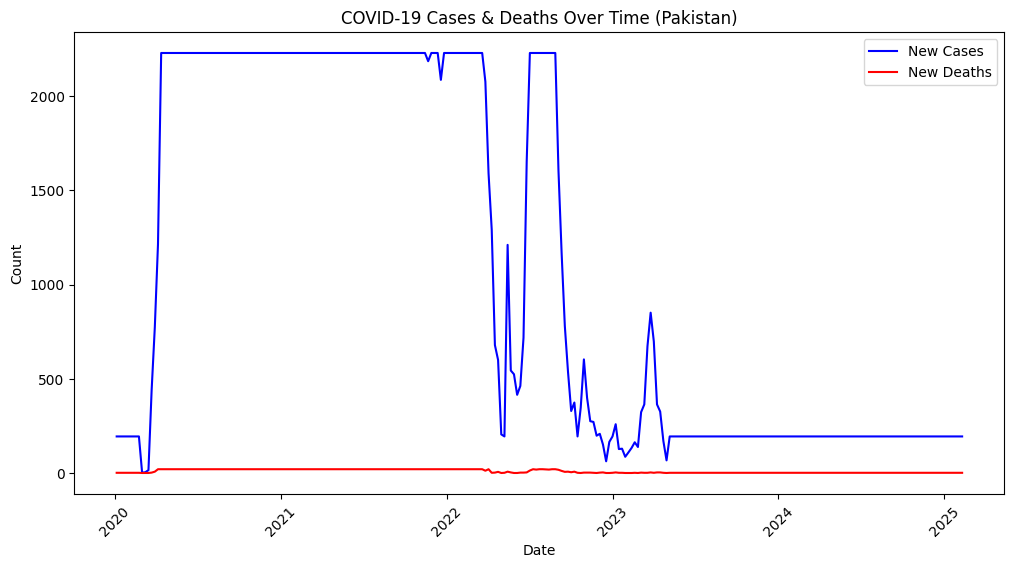

In [19]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(df_pk["Date_reported"], df_pk["New_cases"], label="New Cases", color="blue")
plt.plot(df_pk["Date_reported"], df_pk["New_deaths"], label="New Deaths", color="red")
plt.xlabel("Date")
plt.ylabel("Count")
plt.title("COVID-19 Cases & Deaths Over Time (Pakistan)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [20]:
df_in.head()

,Date_reported,Country_code,Country,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
25632,2020-01-05,IN,India,SEARO,0.0,0,0,0
25633,2020-01-12,IN,India,SEARO,0.0,0,0,0
25634,2020-01-19,IN,India,SEARO,0.0,0,0,0
25635,2020-01-26,IN,India,SEARO,0.0,0,0,0
25636,2020-02-02,IN,India,SEARO,2.0,2,0,0


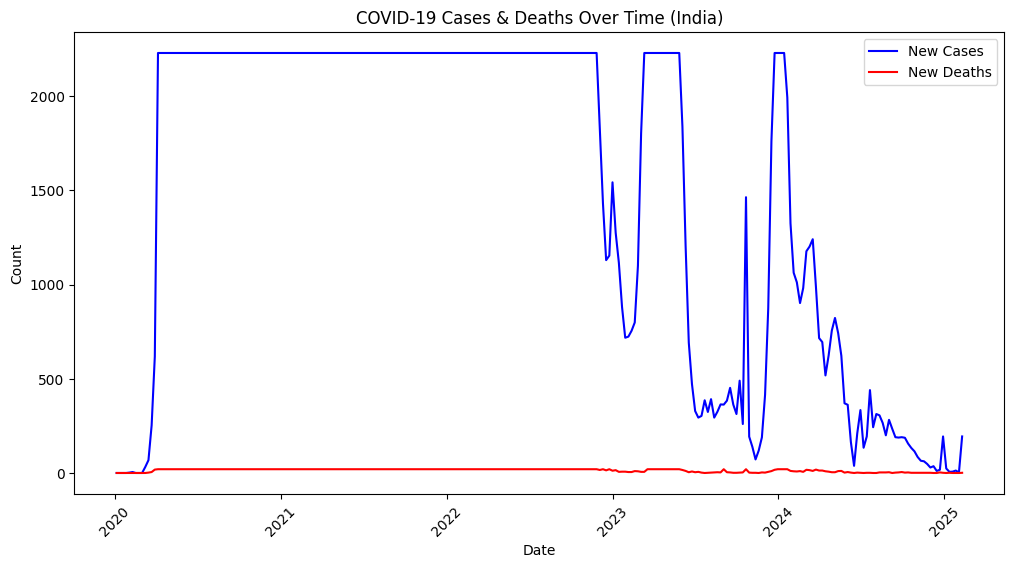

In [21]:
plt.figure(figsize=(12, 6))
plt.plot(df_in["Date_reported"], df_in["New_cases"], label="New Cases", color="blue")
plt.plot(df_in["Date_reported"], df_in["New_deaths"], label="New Deaths", color="red")
plt.xlabel("Date")
plt.ylabel("Count")

plt.title("COVID-19 Cases & Deaths Over Time (India)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [22]:
df_usa.head()

,Date_reported,Country_code,Country,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
61143,2020-01-05,US,United States of America,AMRO,194.0,0,1,0
61144,2020-01-12,US,United States of America,AMRO,194.0,0,1,0
61145,2020-01-19,US,United States of America,AMRO,194.0,0,1,0
61146,2020-01-26,US,United States of America,AMRO,7.0,7,0,0
61147,2020-02-02,US,United States of America,AMRO,2.0,9,0,0


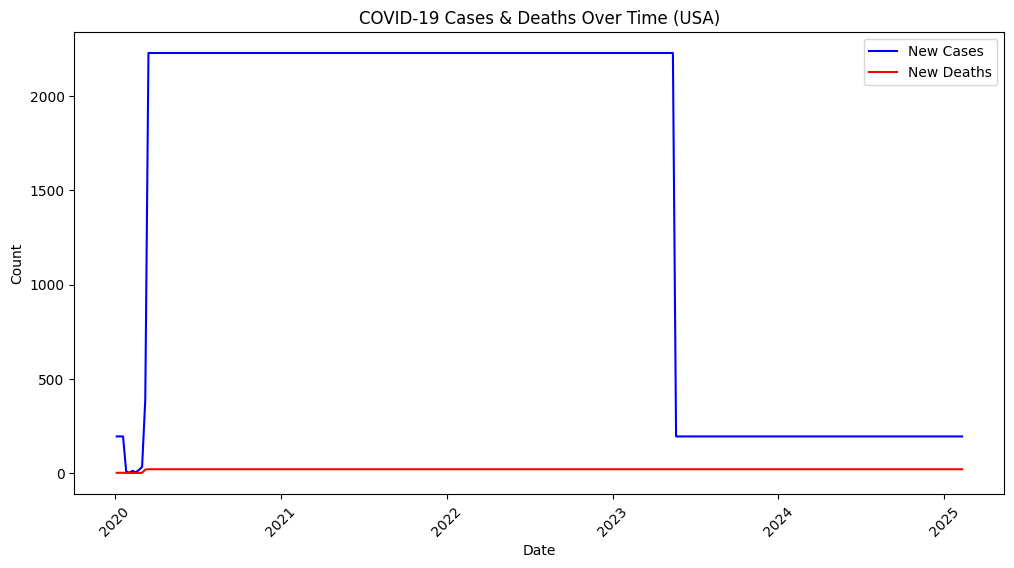

In [23]:
plt.figure(figsize=(12, 6))
plt.plot(df_usa["Date_reported"], df_usa["New_cases"], label="New Cases", color="blue")
plt.plot(df_usa["Date_reported"], df_usa["New_deaths"], label="New Deaths", color="red")
plt.xlabel("Date")
plt.ylabel("Count")

plt.title("COVID-19 Cases & Deaths Over Time (USA)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

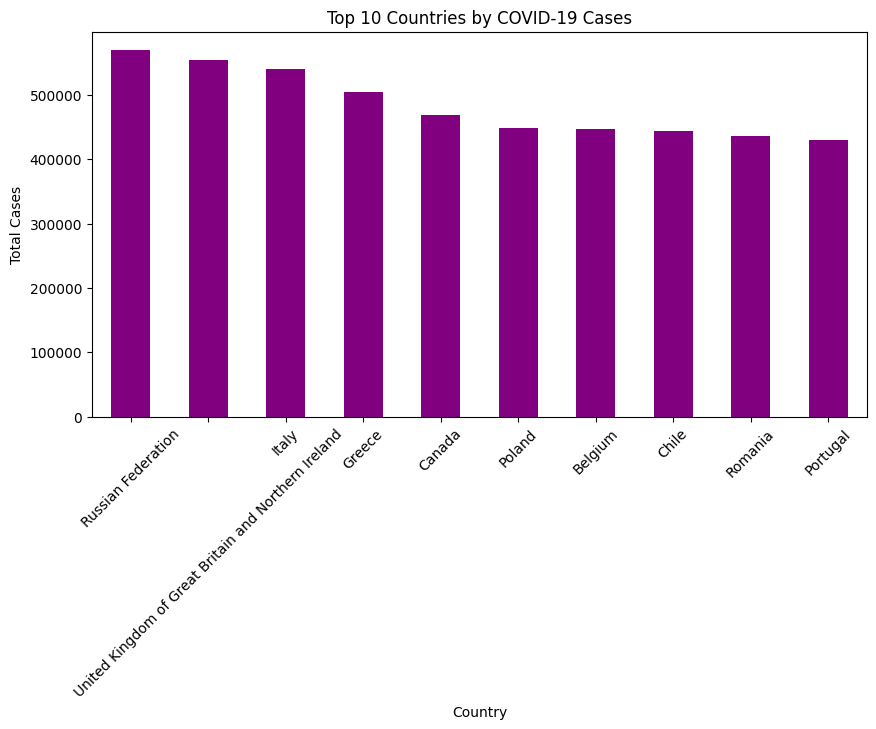

In [24]:
top_countries = df.groupby("Country")["New_cases"].sum().nlargest(10)

plt.figure(figsize=(10, 5))
top_countries.plot(kind="bar", color="purple")
plt.xlabel("Country")
plt.ylabel("Total Cases")
plt.title("Top 10 Countries by COVID-19 Cases")
plt.xticks(rotation=45)
plt.show()


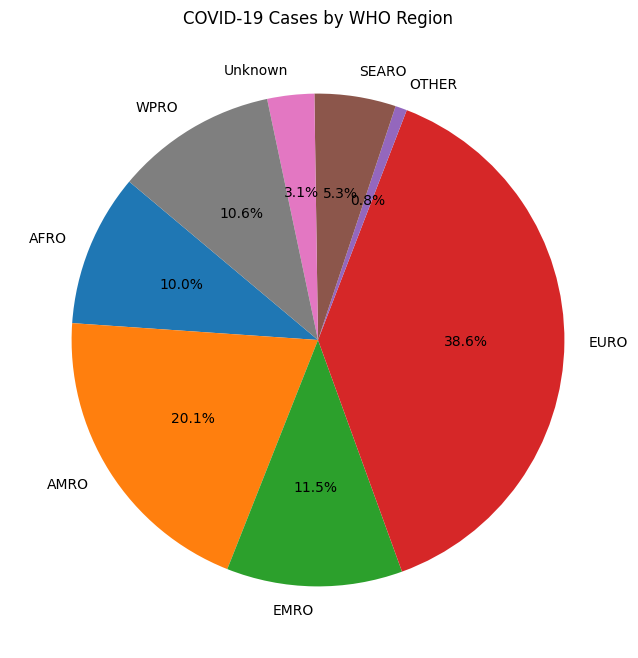

In [25]:
region_cases = df.groupby("WHO_region")["New_cases"].sum()

plt.figure(figsize=(8, 8))
plt.pie(region_cases, labels=region_cases.index, autopct="%1.1f%%", startangle=140)
plt.title("COVID-19 Cases by WHO Region")
plt.show()
